In [37]:
import pandas as pd

folder = r'C:\Users\Prashant Bhalla\Desktop\Prashant-Docs\MMU\MSc Project\new'
df = pd.read_csv(folder + r'\historic_demand_2009_2024.csv')

# Date range
df['settlement_date'] = pd.to_datetime(df['settlement_date'])
print("Date range:", df['settlement_date'].min(), "→", df['settlement_date'].max())

# Periods per day check
print("Settlement periods per day:", df['settlement_period'].max())

# Target variable stats
print("\nNational Demand (nd) stats:")
print(df['nd'].describe())

# Missing values summary (only show columns with nulls)
nulls = df.isnull().sum()
print("\nColumns with missing values:")
print(nulls[nulls > 0])

# Quick yearly demand trend
df['year'] = df['settlement_date'].dt.year
print("\nAverage national demand by year:")
print(df.groupby('year')['nd'].mean().round(0))

Date range: 2009-01-01 00:00:00 → 2024-12-05 00:00:00
Settlement periods per day: 50

National Demand (nd) stats:
count    279264.000000
mean      31186.565042
std        7827.270027
min       13367.000000
25%       24908.000000
50%       30495.000000
75%       36913.000000
max       59095.000000
Name: nd, dtype: float64

Columns with missing values:
nsl_flow             175296
eleclink_flow        175296
scottish_transfer    245424
viking_flow          245424
greenlink_flow       262944
dtype: int64

Average national demand by year:
year
2009    35919.0
2010    36535.0
2011    35150.0
2012    35181.0
2013    34885.0
2014    33169.0
2015    32223.0
2016    31375.0
2017    30373.0
2018    30247.0
2019    29358.0
2020    27157.0
2021    28345.0
2022    26622.0
2023    26052.0
2024    26042.0
Name: nd, dtype: float64


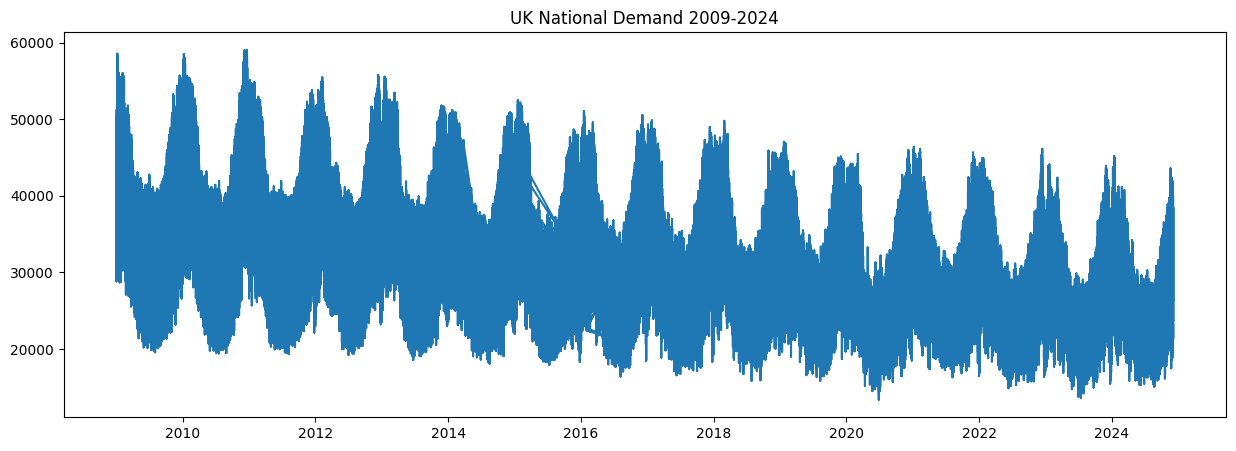

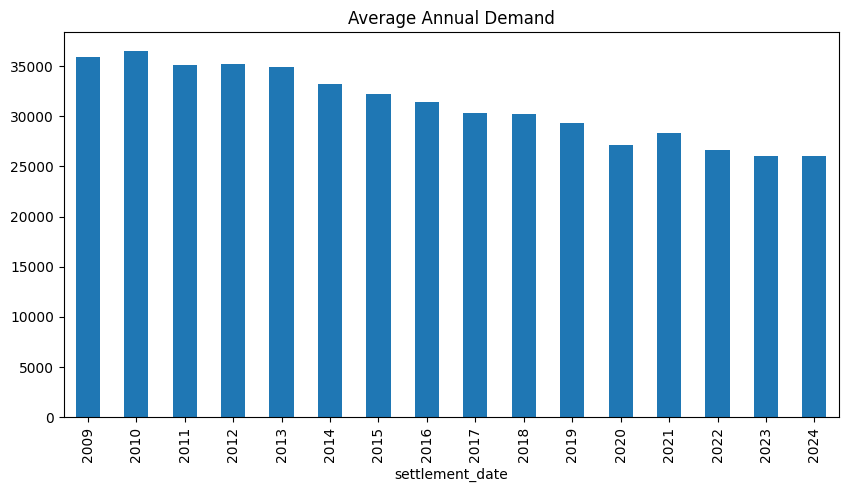

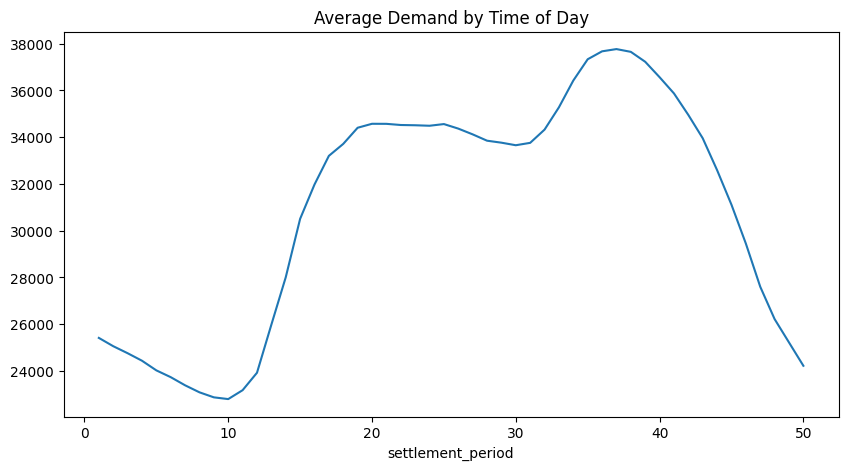

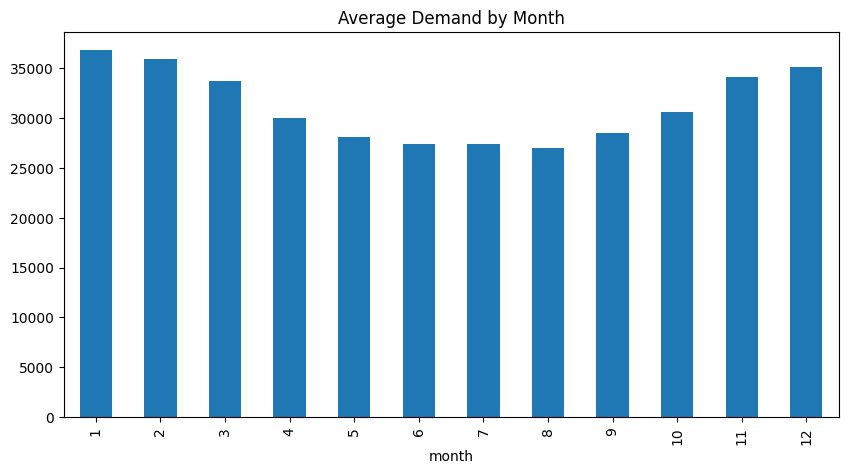

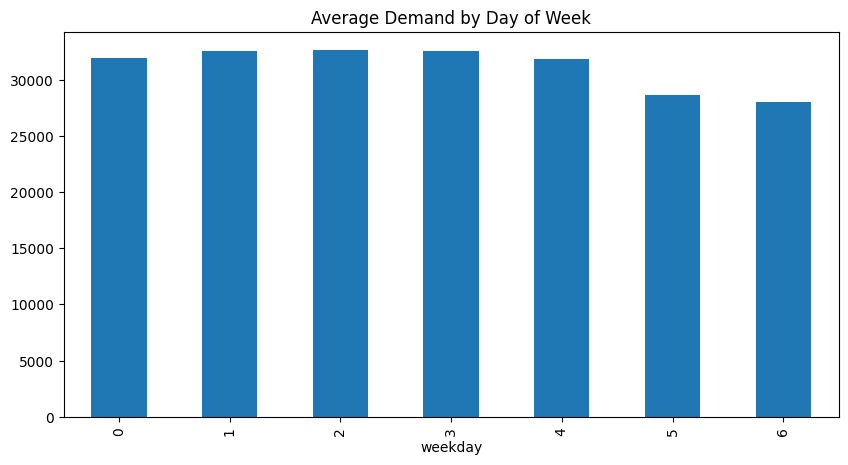

In [38]:
import matplotlib.pyplot as plt

# 1. Demand over time (full 15 years)
plt.figure(figsize=(15,5))
plt.plot(df['settlement_date'], df['nd'])
plt.title('UK National Demand 2009-2024')
plt.show()

# 2. Yearly average demand (shows the declining trend + COVID dip)
yearly = df.groupby(df['settlement_date'].dt.year)['nd'].mean()
yearly.plot(kind='bar', figsize=(10,5))
plt.title('Average Annual Demand')
plt.show()

# 3. Daily pattern (average demand by settlement period)
daily_pattern = df.groupby('settlement_period')['nd'].mean()
daily_pattern.plot(figsize=(10,5))
plt.title('Average Demand by Time of Day')
plt.show()

# 4. Seasonality - monthly pattern
df['month'] = df['settlement_date'].dt.month
monthly = df.groupby('month')['nd'].mean()
monthly.plot(kind='bar', figsize=(10,5))
plt.title('Average Demand by Month')
plt.show()

# 5. Weekday vs weekend
df['weekday'] = df['settlement_date'].dt.dayofweek
weekday_pattern = df.groupby('weekday')['nd'].mean()
weekday_pattern.plot(kind='bar', figsize=(10,5))
plt.title('Average Demand by Day of Week')
plt.show()

In [39]:
df['settlement_date'] = pd.to_datetime(df['settlement_date'])
print("Original shape:", df.shape)

Original shape: (279264, 27)


In [40]:
df = df[df['settlement_period'] <= 48].copy()
print("After removing DST anomaly:", df.shape)

After removing DST anomaly: (279232, 27)


In [41]:
df['datetime'] = df['settlement_date'] + pd.to_timedelta((df['settlement_period'] - 1) * 30, unit='m')
df = df.sort_values('datetime').reset_index(drop=True)
print(df[['datetime', 'settlement_period', 'nd']].head())

             datetime  settlement_period     nd
0 2009-01-01 00:00:00                  1  37910
1 2009-01-01 00:30:00                  2  38047
2 2009-01-01 01:00:00                  3  37380
3 2009-01-01 01:30:00                  4  36426
4 2009-01-01 02:00:00                  5  35687


In [42]:
df['is_covid'] = ((df['datetime'] >= '2020-03-23') & (df['datetime'] <= '2021-07-19')).astype(int)
print(df['is_covid'].value_counts())

is_covid
0    256051
1     23181
Name: count, dtype: int64


In [43]:
interconnector_cols = ['nsl_flow', 'eleclink_flow', 'scottish_transfer', 'viking_flow', 'greenlink_flow']
df[interconnector_cols] = df[interconnector_cols].fillna(0)
print("Remaining missing values:\n", df.isnull().sum().sum())

Remaining missing values:
 0


In [44]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['year'] = df['datetime'].dt.year

In [45]:
df['lag_1'] = df['nd'].shift(1)           # previous half hour
df['lag_2'] = df['nd'].shift(2)           # 1 hour ago
df['lag_48'] = df['nd'].shift(48)         # same time yesterday
df['lag_336'] = df['nd'].shift(336)       # same time last week

In [46]:
df['rolling_mean_48'] = df['nd'].rolling(window=48).mean()   # 1-day rolling average
df['rolling_std_48'] = df['nd'].rolling(window=48).std()
df['rolling_mean_336'] = df['nd'].rolling(window=336).mean() # 1-week rolling average

In [47]:
print("Before dropping NaN:", df.shape)
df = df.dropna().reset_index(drop=True)
print("After dropping NaN:", df.shape)

Before dropping NaN: (279232, 38)
After dropping NaN: (278896, 38)


In [48]:
train = df[df['datetime'] < '2023-01-01'].copy()
test = df[df['datetime'] >= '2023-01-01'].copy()

print("Train shape:", train.shape, "| Date range:", train['datetime'].min(), "→", train['datetime'].max())
print("Test shape:", test.shape, "| Date range:", test['datetime'].min(), "→", test['datetime'].max())

Train shape: (245060, 38) | Date range: 2009-01-08 00:00:00 → 2022-12-31 23:30:00
Test shape: (33836, 38) | Date range: 2023-01-01 00:00:00 → 2024-12-05 23:30:00


In [49]:
train.to_csv(folder + r'\train.csv', index=False)
test.to_csv(folder + r'\test.csv', index=False)
print("Saved successfully")

Saved successfully


In [50]:
# Confirm no missing values remain anywhere
print("Total missing values:", df.isnull().sum().sum())

# Confirm settlement periods are clean (should only be 1-48)
print("Unique settlement periods:", sorted(df['settlement_period'].unique()))

# Confirm datetime is continuous with no gaps
expected_rows = len(pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='30min'))
print(f"Expected rows if no gaps: {expected_rows}, Actual rows: {len(df)}")

# Confirm COVID flag looks right
print(df[df['is_covid']==1]['datetime'].min(), "→", df[df['is_covid']==1]['datetime'].max())

# Quick peek at final columns
print("\nFinal columns:", df.columns.tolist())
print("\nFinal shape:", df.shape)

Total missing values: 0
Unique settlement periods: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48)]
Expected rows if no gaps: 278928, Actual rows: 278896
2020-03-23 00:00:00 → 2021-07-19 00:00:00

Final columns: ['Unnamed: 0', 'settlement_date', 'settlement_period', 'nd', 'tsd', 'england_wales_demand', 'embedded_wind_generation', 'embedded_wind_capacity', 'embedded_solar_generation'

In [51]:
import matplotlib.pyplot as plt

# Reload the processed train/test if needed
train = pd.read_csv(folder + r'\train.csv', parse_dates=['datetime'])
test = pd.read_csv(folder + r'\test.csv', parse_dates=['datetime'])

print("Train:", train.shape, "|", train['datetime'].min(), "→", train['datetime'].max())
print("Test: ", test.shape, "|", test['datetime'].min(), "→", test['datetime'].max())

Train: (245060, 38) | 2009-01-08 00:00:00 → 2022-12-31 23:30:00
Test:  (33836, 38) | 2023-01-01 00:00:00 → 2024-12-05 23:30:00


Train vs Test split visually

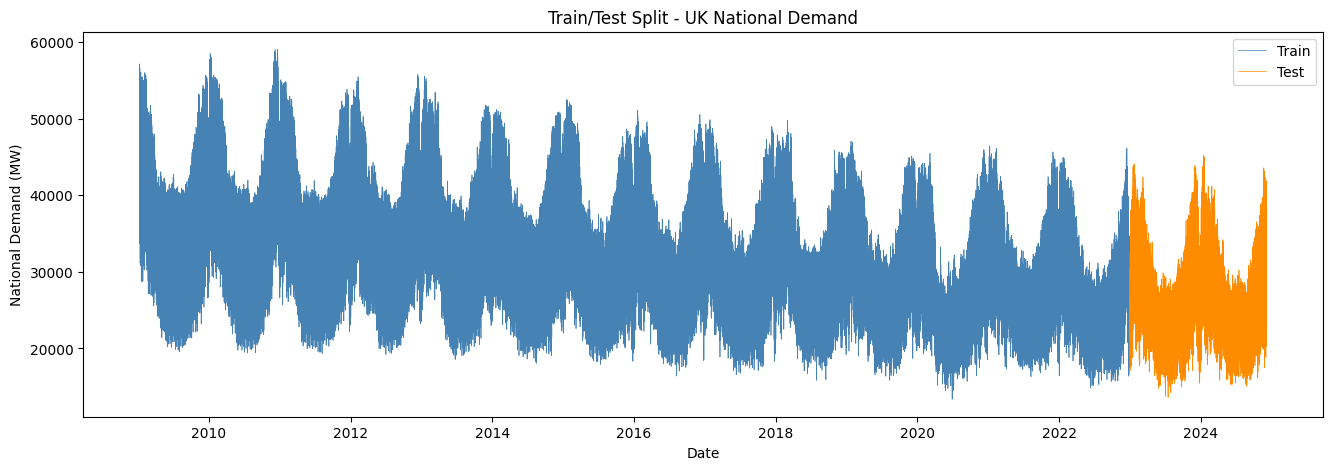

In [52]:
plt.figure(figsize=(16,5))
plt.plot(train['datetime'], train['nd'], label='Train', color='steelblue', linewidth=0.5)
plt.plot(test['datetime'], test['nd'], label='Test', color='darkorange', linewidth=0.5)
plt.title('Train/Test Split - UK National Demand')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.show()

 Zoom into test set only

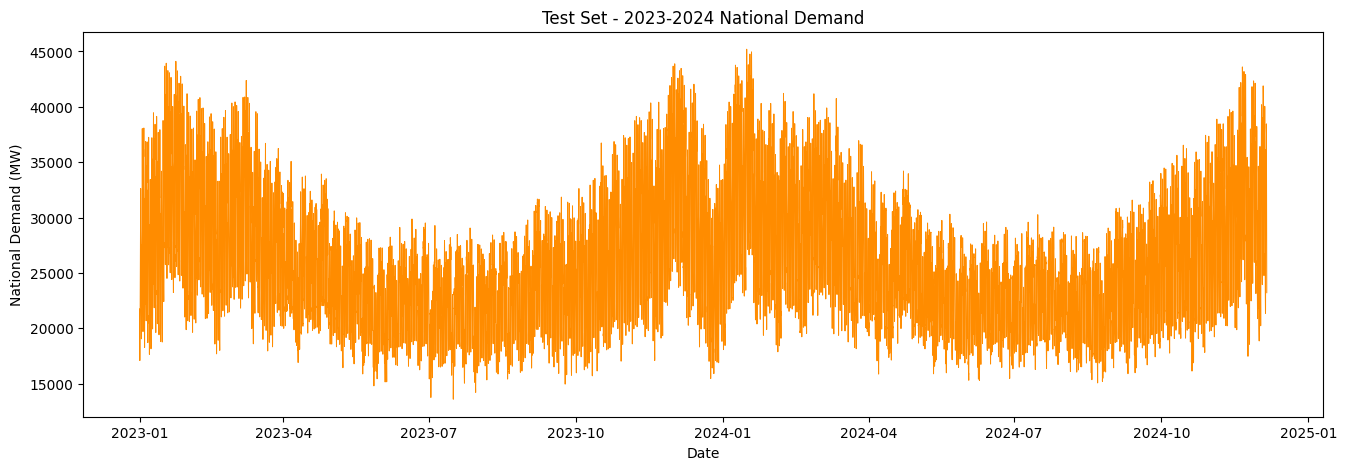

In [53]:
plt.figure(figsize=(16,5))
plt.plot(test['datetime'], test['nd'], color='darkorange', linewidth=0.7)
plt.title('Test Set - 2023-2024 National Demand')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.show()

COVID flag sanity check on the full timeline

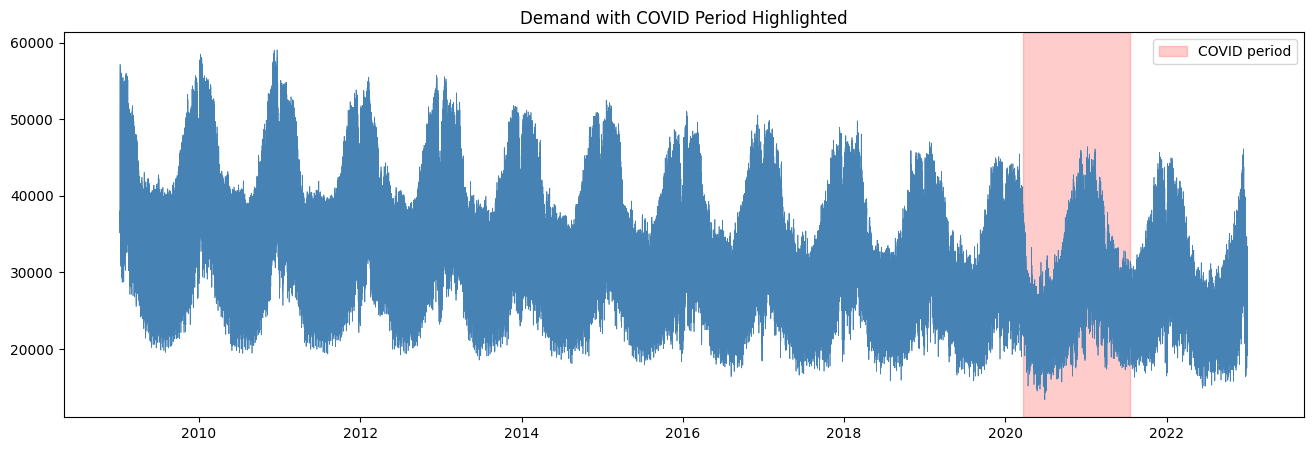

In [54]:
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(train['datetime'], train['nd'], color='steelblue', linewidth=0.5)
covid_period = train[train['is_covid']==1]
ax.axvspan(covid_period['datetime'].min(), covid_period['datetime'].max(), color='red', alpha=0.2, label='COVID period')
ax.set_title('Demand with COVID Period Highlighted')
ax.legend()
plt.show()

Lag and rolling features sanity check

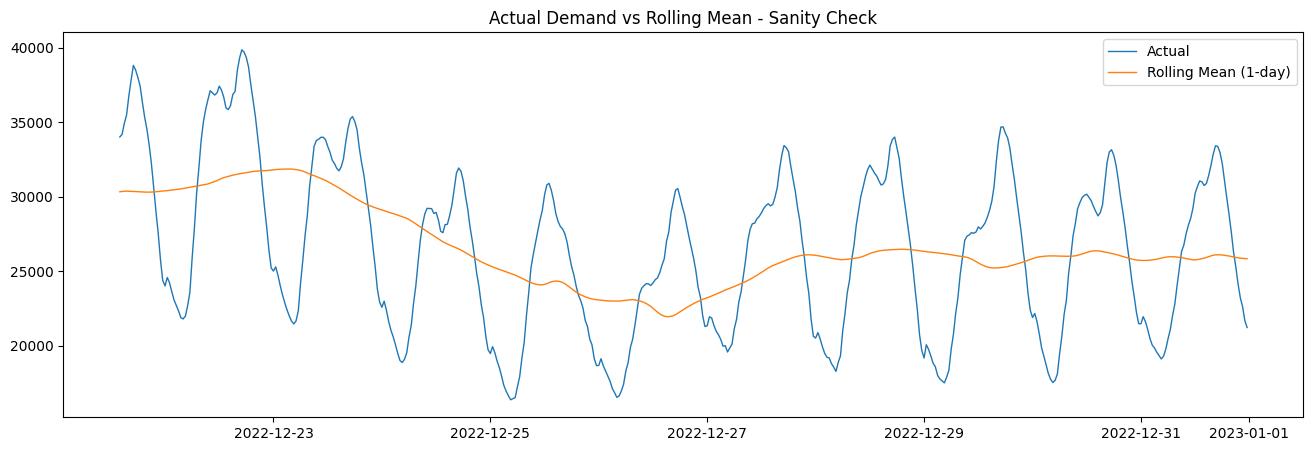

In [55]:
sample = train.tail(500)  # last ~10 days

plt.figure(figsize=(16,5))
plt.plot(sample['datetime'], sample['nd'], label='Actual', linewidth=1)
plt.plot(sample['datetime'], sample['rolling_mean_48'], label='Rolling Mean (1-day)', linewidth=1)
plt.title('Actual Demand vs Rolling Mean - Sanity Check')
plt.legend()
plt.show()

Define Features

In [56]:
# Features to use as inputs
features = [
    'settlement_period',
    'hour',
    'month',
    'weekday',
    'is_weekend',
    'is_holiday',
    'is_covid',
    'embedded_wind_generation',
    'embedded_solar_generation',
    'lag_1',
    'lag_2',
    'lag_48',
    'lag_336',
    'rolling_mean_48',
    'rolling_std_48',
    'rolling_mean_336'
]

target = 'nd'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (245060, 16)
X_test shape: (33836, 16)


In [ ]:
import torch
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Training XGBoost Model

In [57]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("Training complete")

[0]	validation_0-rmse:7911.07977
[100]	validation_0-rmse:397.19741
[200]	validation_0-rmse:333.06202
[300]	validation_0-rmse:315.06581
[400]	validation_0-rmse:307.68483
[499]	validation_0-rmse:302.58442
Training complete


Making Predictions and evaluate

In [58]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("=" * 40)
print("XGBoost Baseline Results")
print("=" * 40)
print(f"RMSE: {rmse:.2f} MW")
print(f"MAE:  {mae:.2f} MW")
print(f"MAPE: {mape:.2f} %")

XGBoost Baseline Results
RMSE: 302.58 MW
MAE:  231.79 MW
MAPE: 0.92 %


Plot predicted vs actual (full test set)

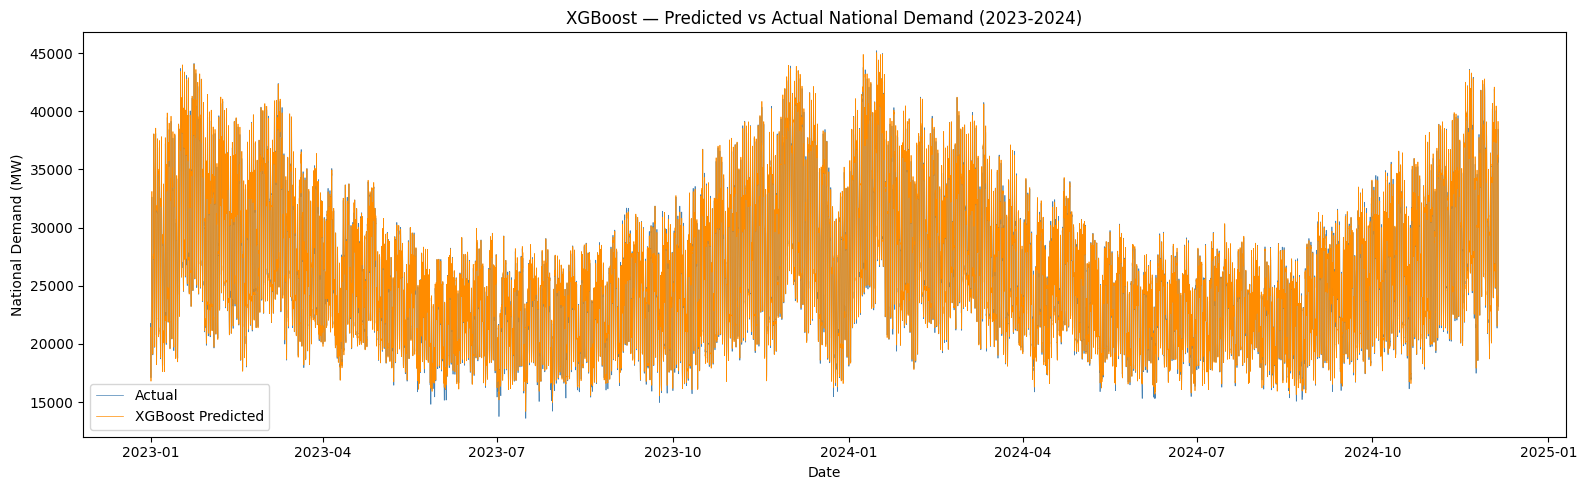

In [59]:
plt.figure(figsize=(16, 5))
plt.plot(test['datetime'], y_test.values, label='Actual', color='steelblue', linewidth=0.5)
plt.plot(test['datetime'], y_pred, label='XGBoost Predicted', color='darkorange', linewidth=0.5)
plt.title('XGBoost — Predicted vs Actual National Demand (2023-2024)')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

Zooming in on one month to see detail

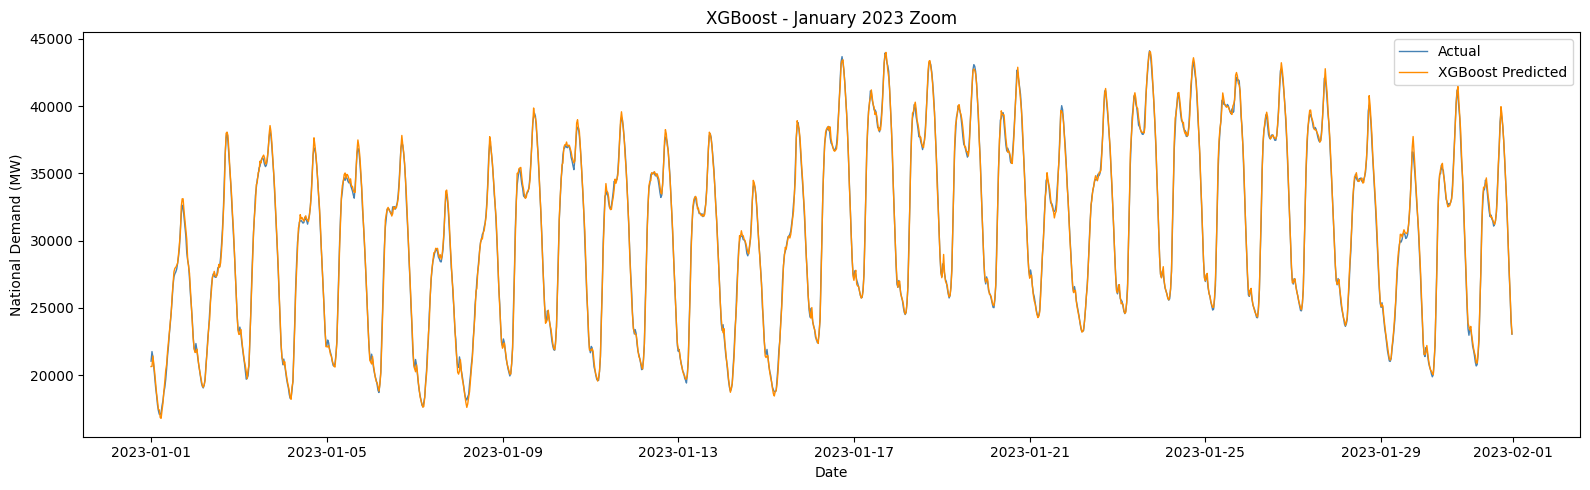

In [60]:
# Zoom into January 2023 for a detailed view
mask = (test['datetime'] >= '2023-01-01') & (test['datetime'] < '2023-02-01')
test_jan = test[mask]
y_test_jan = y_test[mask]
y_pred_jan = y_pred[mask]

plt.figure(figsize=(16, 5))
plt.plot(test_jan['datetime'], y_test_jan.values, label='Actual', color='steelblue', linewidth=1)
plt.plot(test_jan['datetime'], y_pred_jan, label='XGBoost Predicted', color='darkorange', linewidth=1)
plt.title('XGBoost - January 2023 Zoom')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance

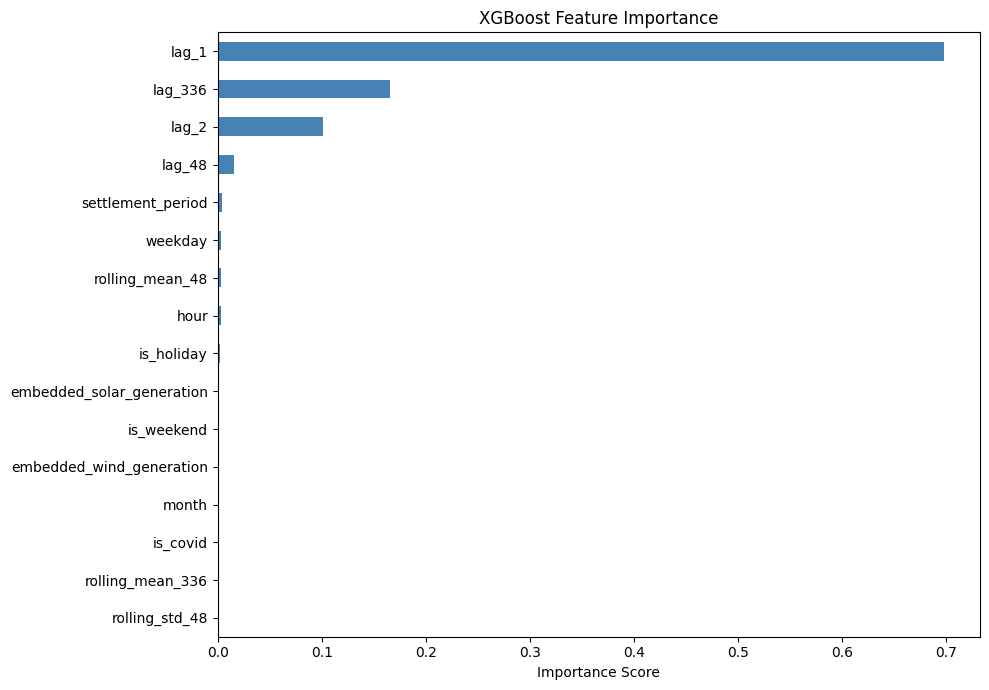

In [61]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [62]:
# Save results to a dictionary for later comparison
results = {
    'Model': ['XGBoost'],
    'RMSE': [302.58],
    'MAE': [231.79],
    'MAPE': [0.92]
}

results_df = pd.DataFrame(results)
results_df.to_csv(folder + r'\model_results.csv', index=False)
print(results_df)

     Model    RMSE     MAE  MAPE
0  XGBoost  302.58  231.79  0.92


Aggregate to daily demand

In [63]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Reload full processed data
train = pd.read_csv(folder + r'\train.csv', parse_dates=['datetime'])
test = pd.read_csv(folder + r'\test.csv', parse_dates=['datetime'])

# Aggregate to daily mean demand
train_daily = train.groupby(train['datetime'].dt.date)['nd'].mean().reset_index()
test_daily = test.groupby(test['datetime'].dt.date)['nd'].mean().reset_index()

train_daily.columns = ['date', 'nd']
test_daily.columns = ['date', 'nd']

train_daily['date'] = pd.to_datetime(train_daily['date'])
test_daily['date'] = pd.to_datetime(test_daily['date'])

print("Train daily shape:", train_daily.shape)
print("Test daily shape:", test_daily.shape)
print(train_daily.head())

Train daily shape: (5106, 2)
Test daily shape: (705, 2)
        date            nd
0 2009-01-08  46168.250000
1 2009-01-09  45964.291667
2 2009-01-10  42028.250000
3 2009-01-11  39155.541667
4 2009-01-12  43611.625000


Check stationarity (ADF test)

In [64]:
# Augmented Dickey-Fuller test
result = adfuller(train_daily['nd'])

print("ADF Stationarity Test")
print("=" * 40)
print(f"ADF Statistic:  {result[0]:.4f}")
print(f"p-value:        {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\nResult: Series is STATIONARY (p < 0.05)")
else:
    print("\nResult: Series is NON-STATIONARY (p > 0.05) — differencing needed")

ADF Stationarity Test
ADF Statistic:  -3.7431
p-value:        0.0035
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671

Result: Series is STATIONARY (p < 0.05)


Plot daily demand to visually inspect

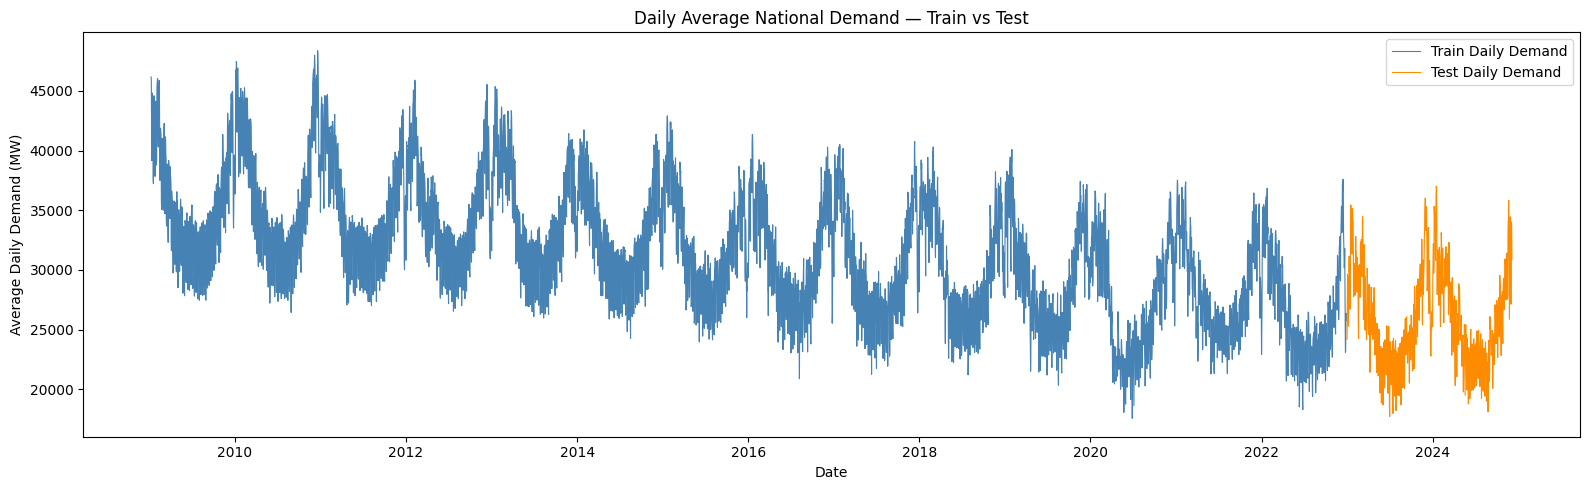

In [65]:
plt.figure(figsize=(16, 5))
plt.plot(train_daily['date'], train_daily['nd'], label='Train Daily Demand', color='steelblue', linewidth=0.8)
plt.plot(test_daily['date'], test_daily['nd'], label='Test Daily Demand', color='darkorange', linewidth=0.8)
plt.title('Daily Average National Demand — Train vs Test')
plt.xlabel('Date')
plt.ylabel('Average Daily Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

Fitting ARIMA model

In [66]:
# Use last 3 years of training data only for speed
# ARIMA doesn't benefit much from very long history
train_arima = train_daily[train_daily['date'] >= '2020-01-01']['nd'].values

print(f"Training ARIMA on {len(train_arima)} daily observations...")
print("This may take 2-5 minutes...")

# ARIMA(p,d,q) — (7,1,1) is a common starting point for daily demand data
# p=7: weekly autoregressive pattern
# d=1: first differencing for stationarity
# q=1: moving average term
arima_model = ARIMA(train_arima, order=(7, 1, 1))
arima_fitted = arima_model.fit()

print("\nARIMA Model Summary:")
print(arima_fitted.summary())

Training ARIMA on 1096 daily observations...
This may take 2-5 minutes...

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1096
Model:                 ARIMA(7, 1, 1)   Log Likelihood               -9523.478
Date:                Sun, 09 Aug 2026   AIC                          19064.956
Time:                        12:06:20   BIC                          19109.943
Sample:                             0   HQIC                         19081.979
                               - 1096                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0006      0.057      0.010      0.992      -0.110       0.112
ar.L2         -0.2436      0.017   

Generate forecasts

In [67]:
n_test = len(test_daily)

# Forecast n_test steps ahead
forecast = arima_fitted.forecast(steps=n_test)

y_test_arima = test_daily['nd'].values
y_pred_arima = forecast

# Calculate metrics
rmse_arima = np.sqrt(mean_squared_error(y_test_arima, y_pred_arima))
mae_arima = mean_absolute_error(y_test_arima, y_pred_arima)
mape_arima = np.mean(np.abs((y_test_arima - y_pred_arima) / y_test_arima)) * 100

print("=" * 40)
print("ARIMA Baseline Results (Daily)")
print("=" * 40)
print(f"RMSE: {rmse_arima:.2f} MW")
print(f"MAE:  {mae_arima:.2f} MW")
print(f"MAPE: {mape_arima:.2f} %")

ARIMA Baseline Results (Daily)
RMSE: 4088.88 MW
MAE:  3321.19 MW
MAPE: 12.64 %


Plot ARIMA Predictions

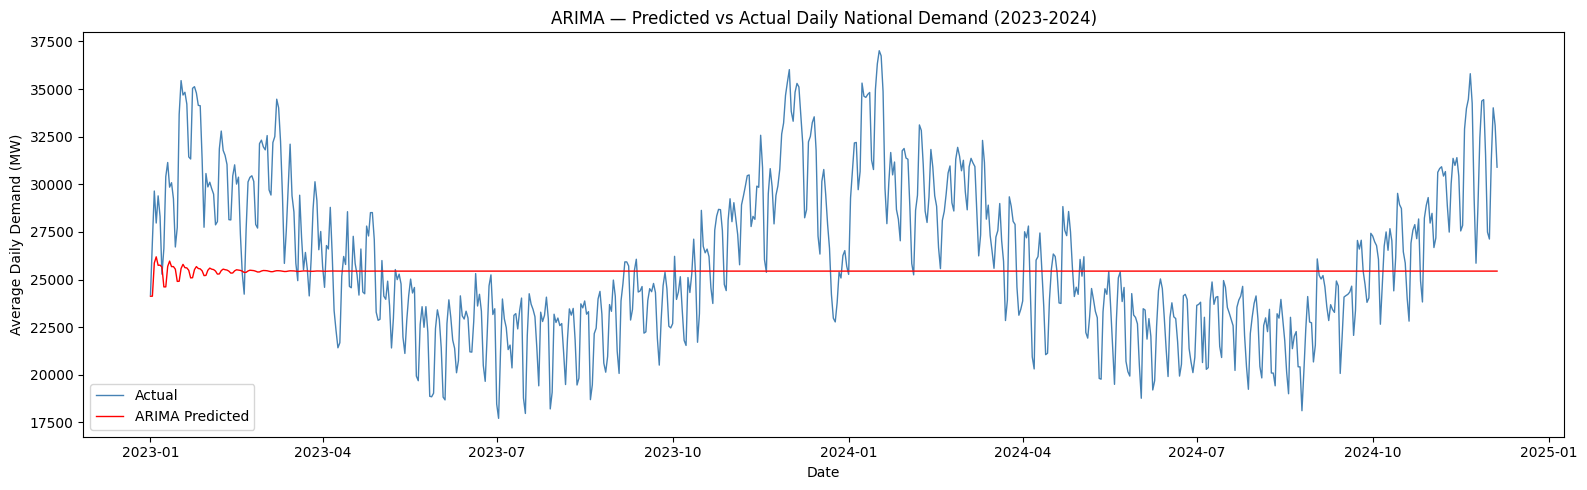

In [68]:
plt.figure(figsize=(16, 5))
plt.plot(test_daily['date'], y_test_arima, label='Actual', color='steelblue', linewidth=1)
plt.plot(test_daily['date'], y_pred_arima, label='ARIMA Predicted', color='red', linewidth=1)
plt.title('ARIMA — Predicted vs Actual Daily National Demand (2023-2024)')
plt.xlabel('Date')
plt.ylabel('Average Daily Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

Update results table

In [69]:
results_df = pd.read_csv(folder + '/model_results.csv')

arima_results = pd.DataFrame({
    'Model': ['ARIMA (daily)'],
    'RMSE': [round(rmse_arima, 2)],
    'MAE': [round(mae_arima, 2)],
    'MAPE': [round(mape_arima, 2)]
})

results_df = pd.concat([results_df, arima_results], ignore_index=True)
results_df.to_csv(folder + '/model_results.csv', index=False)
print(results_df)

           Model     RMSE      MAE   MAPE
0        XGBoost   302.58   231.79   0.92
1  ARIMA (daily)  4088.88  3321.19  12.64


In [70]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

features = [
    'nd', 'settlement_period', 'hour', 'month', 'weekday',
    'is_weekend', 'is_holiday', 'is_covid',
    'embedded_wind_generation', 'embedded_solar_generation'
]

train_data = train[features].values
test_data = test[features].values

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Using device: cpu
Train scaled shape: (245060, 10)
Test scaled shape: (33836, 10)


Create sequences

In [71]:
def create_sequences(data, look_back, target_idx=0):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

LOOK_BACK = 48  # past 1 day

X_train, y_train = create_sequences(train_scaled, LOOK_BACK)
X_test, y_test = create_sequences(test_scaled, LOOK_BACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (245012, 48, 10)
y_train shape: (245012,)
X_test shape: (33788, 48, 10)


PyTorch Dataset and DataLoader

In [72]:
class DemandDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DemandDataset(X_train, y_train)
test_dataset = DemandDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("Batches per epoch:", len(train_loader))

Batches per epoch: 958


Defining LSTM model

In [73]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]  # take last time step
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze()

model = LSTMModel(input_size=X_train.shape[2]).to(device)
print(model)

LSTMModel(
  (lstm1): LSTM(10, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


Training Setup

In [74]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 20
patience = 5
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

In [75]:
from torch.utils.data import random_split

# Split train into train/val (90/10)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=256, shuffle=False)

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), folder + '/Output/lstm_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/20 | Train Loss: 0.019705 | Val Loss: 0.001395
Epoch 2/20 | Train Loss: 0.002273 | Val Loss: 0.000700
Epoch 3/20 | Train Loss: 0.001127 | Val Loss: 0.000649
Epoch 4/20 | Train Loss: 0.000792 | Val Loss: 0.000565
Epoch 5/20 | Train Loss: 0.000619 | Val Loss: 0.000642
Epoch 6/20 | Train Loss: 0.000489 | Val Loss: 0.000712
Epoch 7/20 | Train Loss: 0.000385 | Val Loss: 0.000886
Epoch 8/20 | Train Loss: 0.000323 | Val Loss: 0.000935
Epoch 9/20 | Train Loss: 0.000259 | Val Loss: 0.000628
Early stopping at epoch 9


Plotting Train History

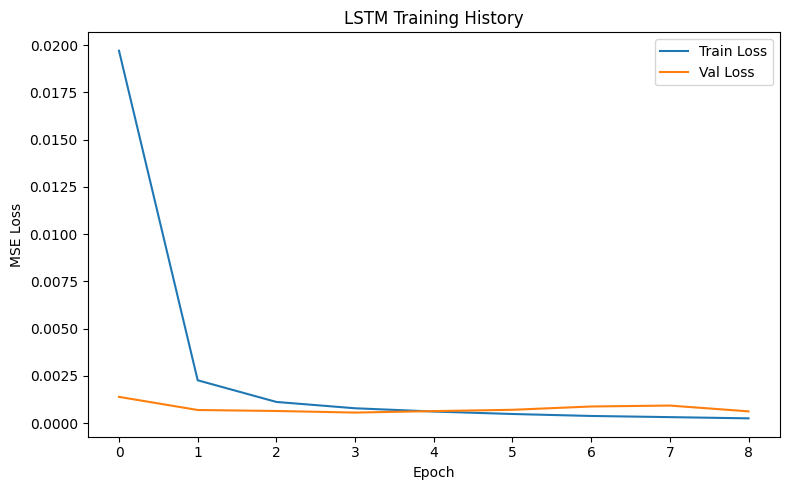

In [76]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

Load best model and predict

In [77]:
model.load_state_dict(torch.load(folder + '/Output/lstm_best.pt'))
model.eval()

test_loader_full = DataLoader(test_dataset, batch_size=256, shuffle=False)

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_full:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

print("Predictions shape:", predictions.shape)

Predictions shape: (33788,)


Inverse transform to real MW values

In [78]:
def inverse_target(scaled_values, scaler, n_features, target_idx=0):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

y_pred_actual = inverse_target(predictions, scaler, len(features))
y_test_actual = inverse_target(actuals, scaler, len(features))

print("Sample predictions vs actual:")
for i in range(5):
    print(f"Actual: {y_test_actual[i]:.0f} MW | Predicted: {y_pred_actual[i]:.0f} MW")

Sample predictions vs actual:
Actual: 21770 MW | Predicted: 21966 MW
Actual: 22351 MW | Predicted: 21493 MW
Actual: 21904 MW | Predicted: 21269 MW
Actual: 21285 MW | Predicted: 21046 MW
Actual: 20818 MW | Predicted: 20871 MW


In [79]:
#Evaluate
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
mape_lstm = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("=" * 40)
print("LSTM Results")
print("=" * 40)
print(f"RMSE: {rmse_lstm:.2f} MW")
print(f"MAE:  {mae_lstm:.2f} MW")
print(f"MAPE: {mape_lstm:.2f} %")

LSTM Results
RMSE: 917.21 MW
MAE:  725.42 MW
MAPE: 2.92 %


Plotting predictions

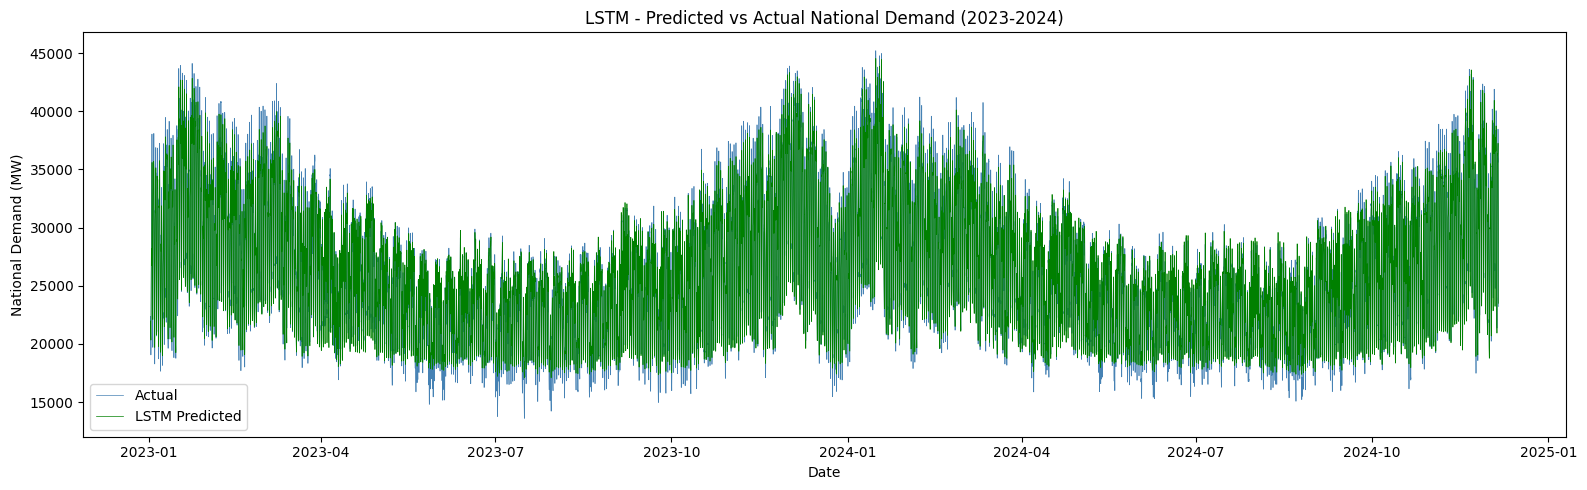

In [80]:
test_dates = test['datetime'].iloc[LOOK_BACK:].reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(test_dates, y_test_actual, label='Actual', color='steelblue', linewidth=0.5)
plt.plot(test_dates, y_pred_actual, label='LSTM Predicted', color='green', linewidth=0.5)
plt.title('LSTM - Predicted vs Actual National Demand (2023-2024)')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

Zoom into January 2023

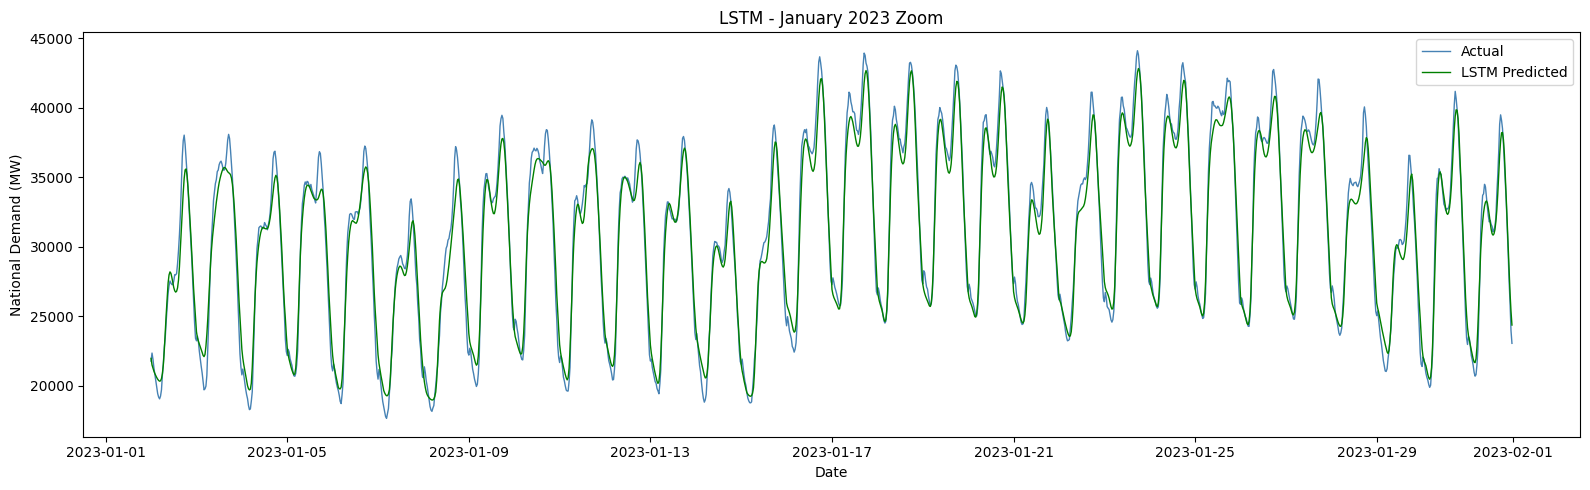

In [81]:
mask = (test_dates >= '2023-01-01') & (test_dates < '2023-02-01')

plt.figure(figsize=(16, 5))
plt.plot(test_dates[mask], y_test_actual[mask], label='Actual', color='steelblue', linewidth=1)
plt.plot(test_dates[mask], y_pred_actual[mask], label='LSTM Predicted', color='green', linewidth=1)
plt.title('LSTM - January 2023 Zoom')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
#Saving Results
results_df = pd.read_csv(folder + r'/Output/model_results.csv')

lstm_results = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [round(rmse_lstm, 2)],
    'MAE': [round(mae_lstm, 2)],
    'MAPE': [round(mape_lstm, 2)]
})

results_df = pd.concat([results_df, lstm_results], ignore_index=True)
results_df.to_csv(folder + r'/Output/model_results.csv', index=False)
print(results_df)

                  Model     RMSE      MAE   MAPE
0               XGBoost   302.58   231.79   0.92
1         ARIMA (daily)  4088.88  3321.19  12.64
2                  LSTM   852.31   681.37   2.71
3                   GRU   481.85   380.98   1.63
4  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40
5                  LSTM   917.21   725.42   2.92


GRU MODEL

In [83]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(GRUModel, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.gru2 = nn.GRU(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc1 = nn.Linear(hidden_size2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.gru1(x)
        out = self.dropout1(out)
        out, _ = self.gru2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze()

gru_model = GRUModel(input_size=X_train.shape[2]).to(device)
print(gru_model)

GRUModel(
  (gru1): GRU(10, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (gru2): GRU(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [84]:
#Training setup for GRU
criterion = nn.MSELoss()
optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.001)

n_epochs = 20
patience = 5
best_val_loss_gru = float('inf')
patience_counter_gru = 0

train_losses_gru = []
val_losses_gru = []

In [85]:
#Training loop for GRU
for epoch in range(n_epochs):
    gru_model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_gru.zero_grad()
        outputs = gru_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_gru.step()
        epoch_train_loss += loss.item()

    gru_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = gru_model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses_gru.append(avg_train_loss)
    val_losses_gru.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss_gru:
        best_val_loss_gru = avg_val_loss
        patience_counter_gru = 0
        torch.save(gru_model.state_dict(), folder + r'/Output/gru_best.pt')
    else:
        patience_counter_gru += 1
        if patience_counter_gru >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/20 | Train Loss: 0.006179 | Val Loss: 0.000684
Epoch 2/20 | Train Loss: 0.000860 | Val Loss: 0.000399
Epoch 3/20 | Train Loss: 0.000521 | Val Loss: 0.000357
Epoch 4/20 | Train Loss: 0.000391 | Val Loss: 0.000407
Epoch 5/20 | Train Loss: 0.000312 | Val Loss: 0.000208
Epoch 6/20 | Train Loss: 0.000258 | Val Loss: 0.000284
Epoch 7/20 | Train Loss: 0.000221 | Val Loss: 0.000313
Epoch 8/20 | Train Loss: 0.000186 | Val Loss: 0.000544
Epoch 9/20 | Train Loss: 0.000169 | Val Loss: 0.000555
Epoch 10/20 | Train Loss: 0.000148 | Val Loss: 0.000602
Early stopping at epoch 10


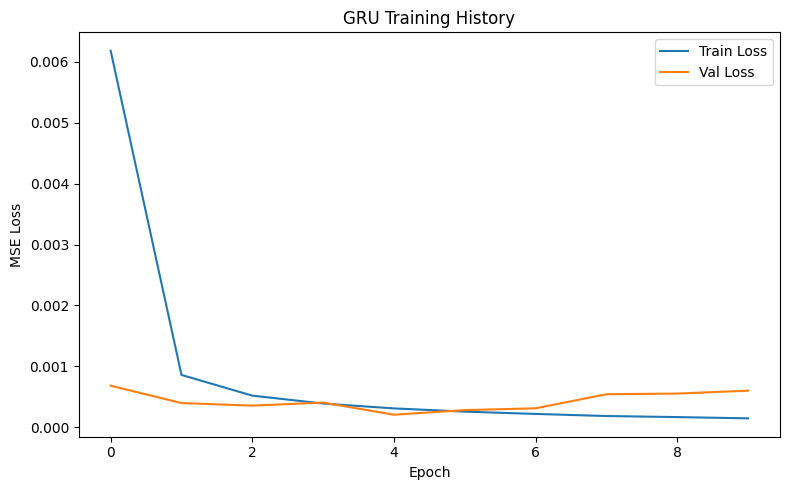

In [86]:
#Plot GRU training history
plt.figure(figsize=(8,5))
plt.plot(train_losses_gru, label='Train Loss')
plt.plot(val_losses_gru, label='Val Loss')
plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Cell 1 - imports + device (few seconds)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cell 2 - load + scale (few seconds)
train = pd.read_csv(folder + '/train.csv', parse_dates=['datetime'])
test = pd.read_csv(folder + '/test.csv', parse_dates=['datetime'])

features = [
    'nd', 'settlement_period', 'hour', 'month', 'weekday',
    'is_weekend', 'is_holiday', 'is_covid',
    'embedded_wind_generation', 'embedded_solar_generation'
]

train_data = train[features].values
test_data = test[features].values

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Cell 3 - sequences (few seconds)
def create_sequences(data, look_back, target_idx=0):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i, target_idx])
    return np.array(X), np.array(y)

LOOK_BACK = 48
X_train, y_train = create_sequences(train_scaled, LOOK_BACK)
X_test, y_test = create_sequences(test_scaled, LOOK_BACK)

def inverse_target(scaled_values, scaler, n_features, target_idx=0):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

# Cell 4 - Dataset/DataLoader (instant)
class DemandDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = DemandDataset(X_train, y_train)
test_dataset = DemandDataset(X_test, y_test)

val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=256, shuffle=False)
test_loader_full = DataLoader(test_dataset, batch_size=256, shuffle=False)

test_dates = test['datetime'].iloc[LOOK_BACK:].reset_index(drop=True)
mask = (test_dates >= '2023-01-01') & (test_dates < '2023-02-01')

print("Setup complete — ready for GRU")

Setup complete — ready for GRU


In [88]:
#Load best GRU model and predict
gru_model.load_state_dict(torch.load(folder + r'/Output/gru_best.pt'))
gru_model.eval()

predictions_gru = []
actuals_gru = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_full:
        X_batch = X_batch.to(device)
        outputs = gru_model(X_batch)
        predictions_gru.extend(outputs.cpu().numpy())
        actuals_gru.extend(y_batch.numpy())

predictions_gru = np.array(predictions_gru)
actuals_gru = np.array(actuals_gru)

print("Predictions shape:", predictions_gru.shape)

Predictions shape: (33788,)


In [89]:
#Inverse transform
y_pred_actual_gru = inverse_target(predictions_gru, scaler, len(features))
y_test_actual_gru = inverse_target(actuals_gru, scaler, len(features))

print("Sample predictions vs actual:")
for i in range(5):
    print(f"Actual: {y_test_actual_gru[i]:.0f} MW | Predicted: {y_pred_actual_gru[i]:.0f} MW")

Sample predictions vs actual:
Actual: 21770 MW | Predicted: 20974 MW
Actual: 22351 MW | Predicted: 21151 MW
Actual: 21904 MW | Predicted: 21611 MW
Actual: 21285 MW | Predicted: 21721 MW
Actual: 20818 MW | Predicted: 21413 MW


In [90]:
#Evaluate
rmse_gru = np.sqrt(mean_squared_error(y_test_actual_gru, y_pred_actual_gru))
mae_gru = mean_absolute_error(y_test_actual_gru, y_pred_actual_gru)
mape_gru = np.mean(np.abs((y_test_actual_gru - y_pred_actual_gru) / y_test_actual_gru)) * 100

print("=" * 40)
print("GRU Results")
print("=" * 40)
print(f"RMSE: {rmse_gru:.2f} MW")
print(f"MAE:  {mae_gru:.2f} MW")
print(f"MAPE: {mape_gru:.2f} %")

GRU Results
RMSE: 491.99 MW
MAE:  387.43 MW
MAPE: 1.55 %


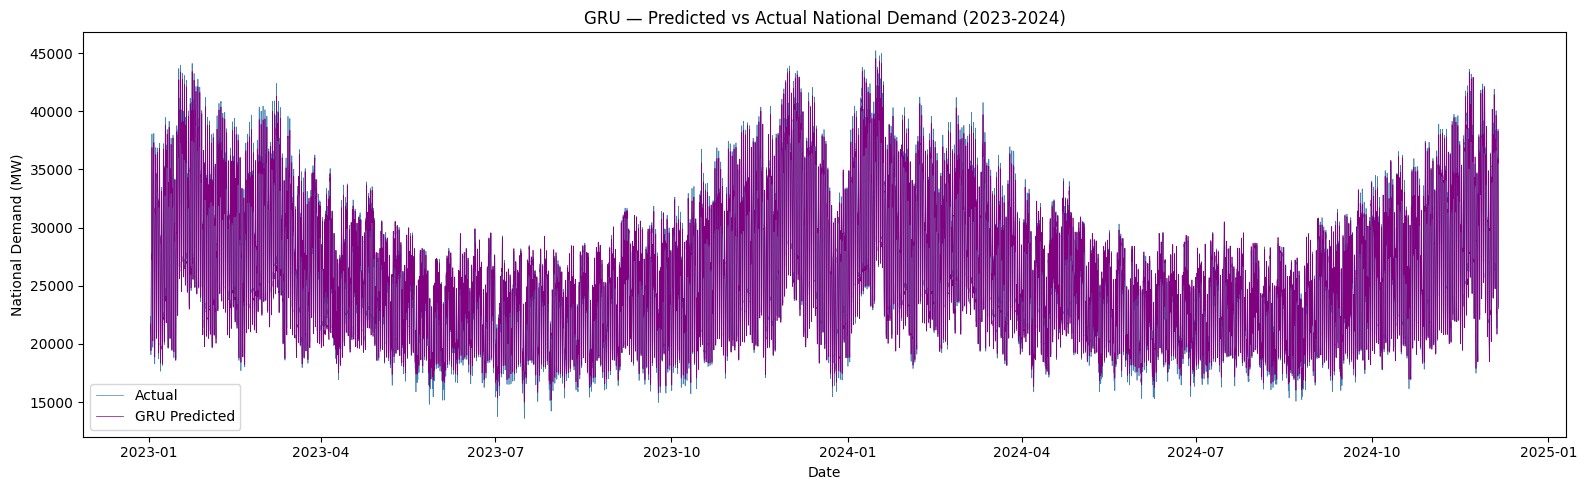

In [91]:
#Plot GRU predictions
plt.figure(figsize=(16, 5))
plt.plot(test_dates, y_test_actual_gru, label='Actual', color='steelblue', linewidth=0.5)
plt.plot(test_dates, y_pred_actual_gru, label='GRU Predicted', color='purple', linewidth=0.5)
plt.title('GRU — Predicted vs Actual National Demand (2023-2024)')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig(folder + r'/Output/gru_full_prediction.png', dpi=150)
plt.show()

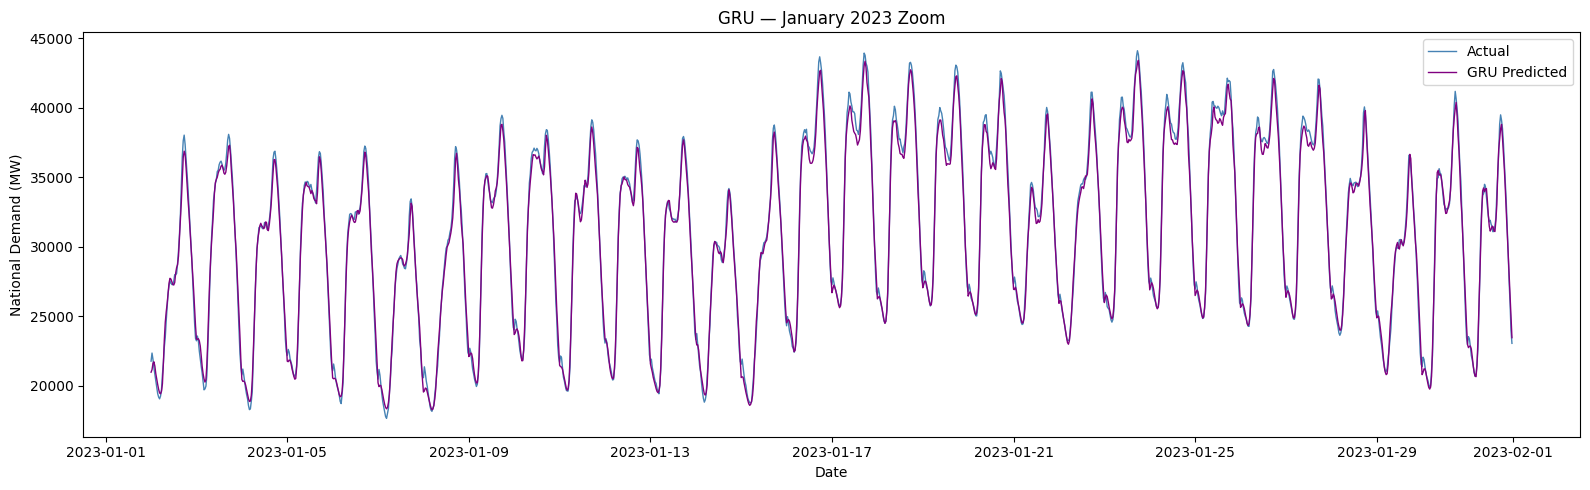

In [92]:
#Zoom into January 2023
plt.figure(figsize=(16, 5))
plt.plot(test_dates[mask], y_test_actual_gru[mask], label='Actual', color='steelblue', linewidth=1)
plt.plot(test_dates[mask], y_pred_actual_gru[mask], label='GRU Predicted', color='purple', linewidth=1)
plt.title('GRU — January 2023 Zoom')
plt.xlabel('Date')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig(folder + r'/Output/gru_jan2023_zoom.png', dpi=150)
plt.show()

In [93]:
#Save results and compare all models
results_df = pd.read_csv(folder + r'/Output/model_results.csv')

gru_results = pd.DataFrame({
    'Model': ['GRU'],
    'RMSE': [round(rmse_gru, 2)],
    'MAE': [round(mae_gru, 2)],
    'MAPE': [round(mape_gru, 2)]
})

results_df = pd.concat([results_df, gru_results], ignore_index=True)
results_df.to_csv(folder + r'/Output/model_results.csv', index=False)
print(results_df)

                  Model     RMSE      MAE   MAPE
0               XGBoost   302.58   231.79   0.92
1         ARIMA (daily)  4088.88  3321.19  12.64
2                  LSTM   852.31   681.37   2.71
3                   GRU   481.85   380.98   1.63
4  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40
5                  LSTM   917.21   725.42   2.92
6                   GRU   491.99   387.43   1.55


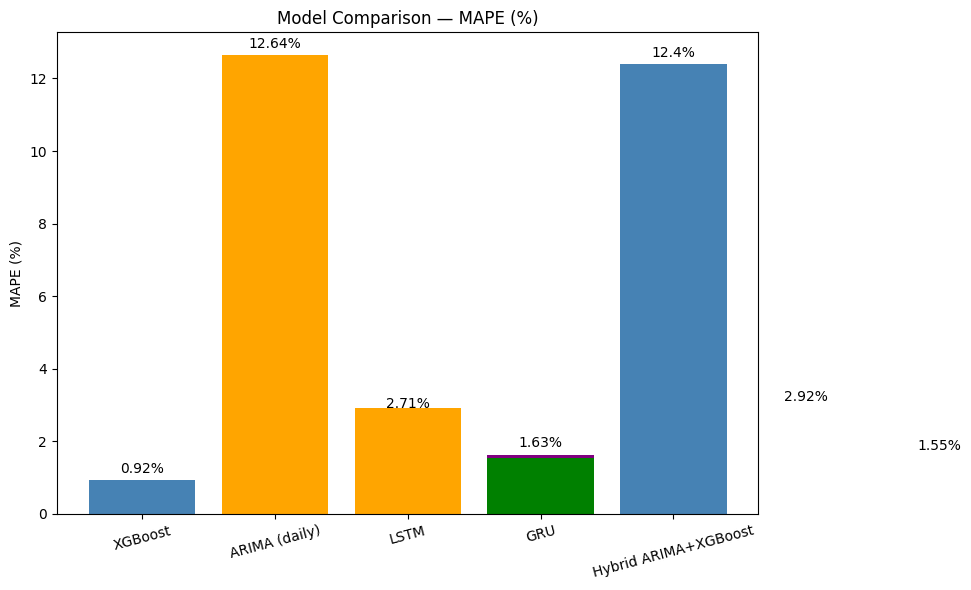

In [94]:
#Final comparison plot: all 4 models side by side
plt.figure(figsize=(10, 6))
x = results_df['Model']
plt.bar(x, results_df['MAPE'], color=['steelblue', 'orange', 'green', 'purple'])
plt.title('Model Comparison — MAPE (%)')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=15)
for i, v in enumerate(results_df['MAPE']):
    plt.text(i, v + 0.2, f"{v}%", ha='center')
plt.tight_layout()
plt.savefig(folder + r'/Output/model_comparison_mape.png', dpi=150)
plt.show()

In [95]:
# Aggregate to daily (for ARIMA component)
train = pd.read_csv(folder + r'\train.csv', parse_dates=['datetime'])
test = pd.read_csv(folder + r'\test.csv', parse_dates=['datetime'])

train_daily = train.groupby(train['datetime'].dt.date)['nd'].mean().reset_index()
test_daily = test.groupby(test['datetime'].dt.date)['nd'].mean().reset_index()
train_daily.columns = ['date', 'nd']
test_daily.columns = ['date', 'nd']
train_daily['date'] = pd.to_datetime(train_daily['date'])
test_daily['date'] = pd.to_datetime(test_daily['date'])

train_arima = train_daily[train_daily['date'] >= '2020-01-01'].reset_index(drop=True)
print("ARIMA training data:", train_arima.shape)

ARIMA training data: (1096, 2)


In [96]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train_arima['nd'].values, order=(7, 1, 1))
arima_fitted = arima_model.fit()

train_arima['arima_pred'] = arima_fitted.fittedvalues
test_forecast = arima_fitted.forecast(steps=len(test_daily))
test_daily['arima_pred'] = test_forecast
print("ARIMA fitted and forecasted.")

ARIMA fitted and forecasted.


In [97]:
# Merge daily ARIMA predictions back to half-hourly data
train['date'] = train['datetime'].dt.date
test['date'] = test['datetime'].dt.date
train_arima['date'] = train_arima['date'].dt.date
test_daily['date'] = test_daily['date'].dt.date

train = train.merge(train_arima[['date', 'arima_pred']], on='date', how='left')
test = test.merge(test_daily[['date', 'arima_pred']], on='date', how='left')

train['residual'] = train['nd'] - train['arima_pred']
test['residual'] = test['nd'] - test['arima_pred']

print(train[['datetime', 'nd', 'arima_pred', 'residual']].head())

             datetime     nd  arima_pred  residual
0 2009-01-08 00:00:00  38055         NaN       NaN
1 2009-01-08 00:30:00  37957         NaN       NaN
2 2009-01-08 01:00:00  37821         NaN       NaN
3 2009-01-08 01:30:00  37165         NaN       NaN
4 2009-01-08 02:00:00  36872         NaN       NaN


In [99]:
# Filter train to match ARIMA training window (2020 onwards) before computing residuals
train = train[train['datetime'] >= '2020-01-01'].copy()
train['residual'] = train['nd'] - train['arima_pred']

print("Residual NaN count after fix:", train['residual'].isnull().sum())
print("Train shape after filtering:", train.shape)

Residual NaN count after fix: 0
Train shape after filtering: (52602, 41)


In [100]:
# XGBoost feature list (your original 16-feature list, not the DL one)
xgb_features = [
    'settlement_period', 'hour', 'month', 'weekday', 'is_weekend',
    'is_holiday', 'is_covid', 'embedded_wind_generation', 'embedded_solar_generation',
    'lag_1', 'lag_2', 'lag_48', 'lag_336', 'rolling_mean_48', 'rolling_std_48', 'rolling_mean_336'
]

X_train_hybrid = train[xgb_features]
y_train_residual = train['residual']
X_test_hybrid = test[xgb_features]

xgb_residual_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_residual_model.fit(X_train_hybrid, y_train_residual)
print("Hybrid XGBoost trained.")

Hybrid XGBoost trained.


In [101]:
residual_pred = xgb_residual_model.predict(X_test_hybrid)
hybrid_pred = test['arima_pred'].values + residual_pred
actual = test['nd'].values

rmse_hybrid = np.sqrt(mean_squared_error(actual, hybrid_pred))
mae_hybrid = mean_absolute_error(actual, hybrid_pred)
mape_hybrid = np.mean(np.abs((actual - hybrid_pred) / actual)) * 100

print(f"RMSE: {rmse_hybrid:.2f} MW")
print(f"MAE:  {mae_hybrid:.2f} MW")
print(f"MAPE: {mape_hybrid:.2f} %")

RMSE: 3853.55 MW
MAE:  3146.97 MW
MAPE: 12.40 %


In [102]:
results_df = pd.read_csv(folder + r'/Output/model_results.csv')
hybrid_results = pd.DataFrame({
    'Model': ['Hybrid ARIMA+XGBoost'],
    'RMSE': [round(rmse_hybrid, 2)],
    'MAE': [round(mae_hybrid, 2)],
    'MAPE': [round(mape_hybrid, 2)]
})
results_df = pd.concat([results_df, hybrid_results], ignore_index=True)
results_df.to_csv(folder + r'/Output/model_results.csv', index=False)
print(results_df)

                  Model     RMSE      MAE   MAPE
0               XGBoost   302.58   231.79   0.92
1         ARIMA (daily)  4088.88  3321.19  12.64
2                  LSTM   852.31   681.37   2.71
3                   GRU   481.85   380.98   1.63
4  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40
5                  LSTM   917.21   725.42   2.92
6                   GRU   491.99   387.43   1.55
7  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40


In [103]:
import pandas as pd

results = pd.read_csv(folder + r'/Output/model_results.csv')
print("Before cleanup:")
print(results)

# Keep only the LAST occurrence of each model (the most recent "Run All" results)
results_clean = results.drop_duplicates(subset='Model', keep='last').reset_index(drop=True)

print("\nAfter cleanup:")
print(results_clean)

results_clean.to_csv(folder + r'/Output/model_results.csv', index=False)

Before cleanup:
                  Model     RMSE      MAE   MAPE
0               XGBoost   302.58   231.79   0.92
1         ARIMA (daily)  4088.88  3321.19  12.64
2                  LSTM   852.31   681.37   2.71
3                   GRU   481.85   380.98   1.63
4  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40
5                  LSTM   917.21   725.42   2.92
6                   GRU   491.99   387.43   1.55
7  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40

After cleanup:
                  Model     RMSE      MAE   MAPE
0               XGBoost   302.58   231.79   0.92
1         ARIMA (daily)  4088.88  3321.19  12.64
2                  LSTM   917.21   725.42   2.92
3                   GRU   491.99   387.43   1.55
4  Hybrid ARIMA+XGBoost  3853.55  3146.97  12.40


In [104]:
test = pd.read_csv(folder + r'/test.csv', parse_dates=['datetime'])
test['date'] = test['datetime'].dt.date

In [118]:
lstm_compare = pd.DataFrame({
    'date': test_dates_lstm.values,
    'actual': y_test_actual,
    'predicted': y_pred_actual
})
lstm_daily = lstm_compare.groupby('date').mean().reset_index()

rmse_lstm_daily = np.sqrt(mean_squared_error(lstm_daily['actual'], lstm_daily['predicted']))
mae_lstm_daily = mean_absolute_error(lstm_daily['actual'], lstm_daily['predicted'])
mape_lstm_daily = np.mean(np.abs((lstm_daily['actual'] - lstm_daily['predicted']) / lstm_daily['actual'])) * 100

print(f"LSTM (daily-aggregated): RMSE {rmse_lstm_daily:.2f} | MAE {mae_lstm_daily:.2f} | MAPE {mape_lstm_daily:.2f}%")

LSTM (daily-aggregated): RMSE 366.25 | MAE 277.08 | MAPE 1.09%


In [122]:
test_dates_lstm = test['date'].iloc[LOOK_BACK:].reset_index(drop=True)

lstm_compare = pd.DataFrame({
    'date': test_dates_lstm.values,
    'actual': y_test_actual,
    'predicted': y_pred_actual
})
lstm_daily = lstm_compare.groupby('date').mean().reset_index()

rmse_lstm_daily = np.sqrt(mean_squared_error(lstm_daily['actual'], lstm_daily['predicted']))
mae_lstm_daily = mean_absolute_error(lstm_daily['actual'], lstm_daily['predicted'])
mape_lstm_daily = np.mean(np.abs((lstm_daily['actual'] - lstm_daily['predicted']) / lstm_daily['actual'])) * 100

print(f"LSTM (daily-aggregated): RMSE {rmse_lstm_daily:.2f} | MAE {mae_lstm_daily:.2f} | MAPE {mape_lstm_daily:.2f}%")

LSTM (daily-aggregated): RMSE 366.25 | MAE 277.08 | MAPE 1.09%


In [123]:
gru_compare = pd.DataFrame({
    'date': test_dates_lstm.values,
    'actual': y_test_actual_gru,
    'predicted': y_pred_actual_gru
})
gru_daily = gru_compare.groupby('date').mean().reset_index()

rmse_gru_daily = np.sqrt(mean_squared_error(gru_daily['actual'], gru_daily['predicted']))
mae_gru_daily = mean_absolute_error(gru_daily['actual'], gru_daily['predicted'])
mape_gru_daily = np.mean(np.abs((gru_daily['actual'] - gru_daily['predicted']) / gru_daily['actual'])) * 100

print(f"GRU (daily-aggregated): RMSE {rmse_gru_daily:.2f} | MAE {mae_gru_daily:.2f} | MAPE {mape_gru_daily:.2f}%")

GRU (daily-aggregated): RMSE 201.73 | MAE 158.75 | MAPE 0.59%


In [124]:
fair_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'GRU', 'LSTM', 'Hybrid ARIMA+XGBoost', 'ARIMA'],
    'RMSE': [95.43, 201.73, 366.25, 3818.22, round(rmse_arima, 2)],
    'MAE': [73.48, 158.75, 277.08, 3118.09, round(mae_arima, 2)],
    'MAPE': [0.29, 0.59, 1.09, 11.94, round(mape_arima, 2)]
})

fair_comparison = fair_comparison.sort_values('MAPE').reset_index(drop=True)
print(fair_comparison)

fair_comparison.to_csv(folder + r'/Output/model_results_daily_fair.csv', index=False)
print("\nSaved to model_results_daily_fair.csv")

                  Model     RMSE      MAE   MAPE
0               XGBoost    95.43    73.48   0.29
1                   GRU   201.73   158.75   0.59
2                  LSTM   366.25   277.08   1.09
3  Hybrid ARIMA+XGBoost  3818.22  3118.09  11.94
4                 ARIMA  4088.88  3321.19  12.64

Saved to model_results_daily_fair.csv


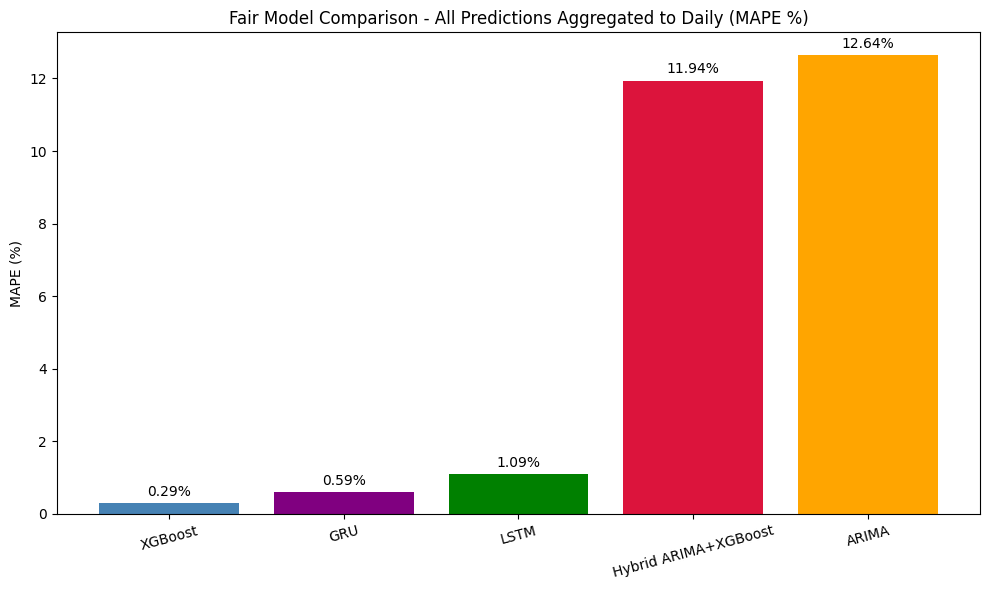

In [126]:
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'purple', 'green', 'crimson', 'orange']
plt.bar(fair_comparison['Model'], fair_comparison['MAPE'], color=colors)
plt.title('Fair Model Comparison - All Predictions Aggregated to Daily (MAPE %)')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=15)
for i, v in enumerate(fair_comparison['MAPE']):
    plt.text(i, v + 0.2, f"{v}%", ha='center')
plt.tight_layout()
plt.savefig(folder + r'/Output/fair_comparison_daily_mape.png', dpi=150)
plt.show()